In [1]:
import numpy as np
import datetime
import pandas as pd
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
client = pd.read_csv('./data/data_berka/client.asc', sep=';')

# Each record describes static characteristics of an account
account = pd.read_csv('./data/data_berka/account.asc', sep=';')

# Each record describes a credit card issued to an account
card = pd.read_csv('./data/data_berka/card.asc', sep=';')

# Each record describes demographic characteristics of a district
district = pd.read_csv('./data/data_berka/district.asc', sep=';')

# Each record relates together a client with an account
# i.e. this relation describes the rights of clients to operate accounts
disp = pd.read_csv('./data/data_berka/disp.asc', sep=';')

# Each record describes characteristics of a payment order (debits only)
order = pd.read_csv('./data/data_berka/order.asc', sep=';')

# Each record describes one transaction on an account
trans = pd.read_csv('./data/data_berka/trans.asc', sep=';', low_memory=False)

# Each record describes a loan granted for a given account
loan = pd.read_csv('./data/data_berka/loan.asc', sep=';')

In [3]:
client.head()

,client_id,birth_number,district_id
0,1,706213,18
1,2,450204,1
2,3,406009,1
3,4,561201,5
4,5,605703,5


In [4]:
client.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5369 entries, 0 to 5368
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   client_id     5369 non-null   int64
 1   birth_number  5369 non-null   int64
 2   district_id   5369 non-null   int64
dtypes: int64(3)
memory usage: 126.0 KB


In [5]:
# Extract the birth year
client['birth_year']= client['birth_number'].astype('str').str[:2].astype('int') + 1900
client['birth_year']

0       1970
1       1945
2       1940
3       1956
4       1960
        ... 
5364    1945
5365    1943
5366    1968
5367    1962
5368    1953
Name: birth_year, Length: 5369, dtype: int64

In [6]:
# Extract the birth month
client['birth_month'] = client['birth_number'].astype(str).str[2:4].astype(int)

# Extract and correct the gender
client['gender'] = 'M'
client.loc[client['birth_month'] > 50, 'gender'] = 'F'

# Correct the birth month
client.loc[client['birth_month'] > 50, 'birth_month'] = client.loc[client['birth_month'] > 50, 'birth_month'] - 50
client.head()

,client_id,birth_number,district_id,birth_year,birth_month,gender
0,1,706213,18,1970,12,F
1,2,450204,1,1945,2,M
2,3,406009,1,1940,10,F
3,4,561201,5,1956,12,M
4,5,605703,5,1960,7,F


In [7]:
# Extract the birth day
client['birth_day'] = client['birth_number'].astype(str).str[4:].astype(int)
client.head()

,client_id,birth_number,district_id,birth_year,birth_month,gender,birth_day
0,1,706213,18,1970,12,F,13
1,2,450204,1,1945,2,M,4
2,3,406009,1,1940,10,F,9
3,4,561201,5,1956,12,M,1
4,5,605703,5,1960,7,F,3


In [8]:
client['age'] = 1999 - client['birth_year']
client.head()

,client_id,birth_number,district_id,birth_year,birth_month,gender,birth_day,age
0,1,706213,18,1970,12,F,13,29
1,2,450204,1,1945,2,M,4,54
2,3,406009,1,1940,10,F,9,59
3,4,561201,5,1956,12,M,1,43
4,5,605703,5,1960,7,F,3,39


In [9]:
client['age_group'] = client['age'] // 10 * 10
client.head()

,client_id,birth_number,district_id,birth_year,birth_month,gender,birth_day,age,age_group
0,1,706213,18,1970,12,F,13,29,20
1,2,450204,1,1945,2,M,4,54,50
2,3,406009,1,1940,10,F,9,59,50
3,4,561201,5,1956,12,M,1,43,40
4,5,605703,5,1960,7,F,3,39,30


In [10]:
client.groupby(['age_group', 'gender']).size().unstack()

gender,F,M
age_group,,
10,79,87
20,525,497
30,479,480
40,478,498
50,511,481
60,279,374
70,250,237
80,44,70


In [11]:
client_agegroup = client.groupby(['age_group', 'gender']).size().unstack()
client_agegroup.head()

gender,F,M
age_group,,
10,79,87
20,525,497
30,479,480
40,478,498
50,511,481


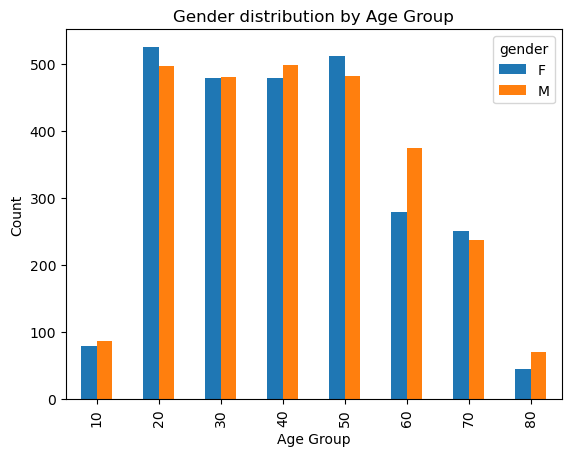

In [12]:
client_agegroup.plot(kind='bar')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.title('Gender distribution by Age Group')
plt.show()

In [13]:
# Groupping data using function
client.groupby('gender')['age'].agg(['mean', 'max', 'min', 'median', 'count'])

,mean,max,min,median,count
gender,,,,,
F,45.398110,85,12,45.0,2645
M,46.193465,88,13,46.0,2724


In [14]:
client.isnull().sum().sum()

np.int64(0)

In [15]:
account.head()

,account_id,district_id,frequency,date
0,576,55,POPLATEK MESICNE,930101
1,3818,74,POPLATEK MESICNE,930101
2,704,55,POPLATEK MESICNE,930101
3,2378,16,POPLATEK MESICNE,930101
4,2632,24,POPLATEK MESICNE,930102


In [16]:
account.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   account_id   4500 non-null   int64 
 1   district_id  4500 non-null   int64 
 2   frequency    4500 non-null   object
 3   date         4500 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 140.8+ KB


In [17]:
account['year'] = account['date'].astype(str).str[:2].astype(int) + 1900

In [18]:
account['lor'] = 1996 -account['year']

In [19]:
# Translate frequency of transactions to English.
def convert_freq_to_eng(x):
    if x == 'POPLATEK MESICNE':
        return 'MONTHLY'
    elif x == 'POPLATEK TYDNE':
        return 'WEEKLY'
    elif x == 'POPLATEK PO OBRATU':
        return 'TRANSACTION'
    else:
        return 'UNKNOWN'
    
account['frequency_eng'] = account['frequency'].apply(lambda x: convert_freq_to_eng(x))
account.head()

,account_id,district_id,frequency,date,year,lor,frequency_eng
0,576,55,POPLATEK MESICNE,930101,1993,3,MONTHLY
1,3818,74,POPLATEK MESICNE,930101,1993,3,MONTHLY
2,704,55,POPLATEK MESICNE,930101,1993,3,MONTHLY
3,2378,16,POPLATEK MESICNE,930101,1993,3,MONTHLY
4,2632,24,POPLATEK MESICNE,930102,1993,3,MONTHLY


In [20]:
account.isna().sum()

account_id       0
district_id      0
frequency        0
date             0
year             0
lor              0
frequency_eng    0
dtype: int64

<Axes: xlabel='frequency_eng', ylabel='count'>

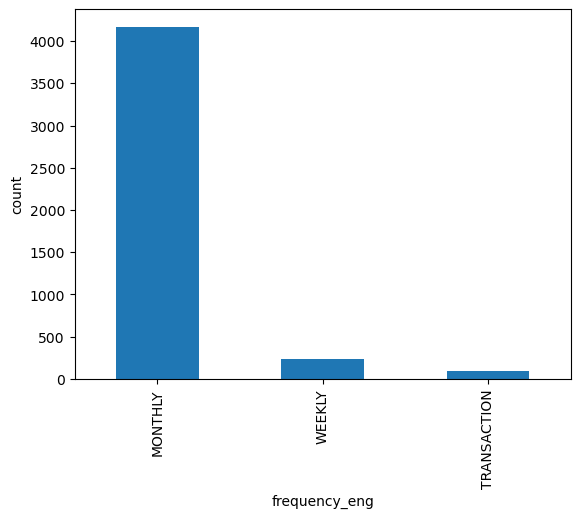

In [21]:
account['frequency_eng'].value_counts().plot(kind ='bar',ylabel='count')

In [22]:
account_base = account.drop(['frequency'],axis=1)

In [23]:
account_base.head()

,account_id,district_id,date,year,lor,frequency_eng
0,576,55,930101,1993,3,MONTHLY
1,3818,74,930101,1993,3,MONTHLY
2,704,55,930101,1993,3,MONTHLY
3,2378,16,930101,1993,3,MONTHLY
4,2632,24,930102,1993,3,MONTHLY


In [24]:
disp.head()

,disp_id,client_id,account_id,type
0,1,1,1,OWNER
1,2,2,2,OWNER
2,3,3,2,DISPONENT
3,4,4,3,OWNER
4,5,5,3,DISPONENT


In [25]:
disp.isna().sum()

disp_id       0
client_id     0
account_id    0
type          0
dtype: int64

In [26]:
disp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5369 entries, 0 to 5368
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   disp_id     5369 non-null   int64 
 1   client_id   5369 non-null   int64 
 2   account_id  5369 non-null   int64 
 3   type        5369 non-null   object
dtypes: int64(3), object(1)
memory usage: 167.9+ KB


In [27]:
disp['type'].value_counts()

type
OWNER        4500
DISPONENT     869
Name: count, dtype: int64

<Axes: xlabel='type', ylabel='count'>

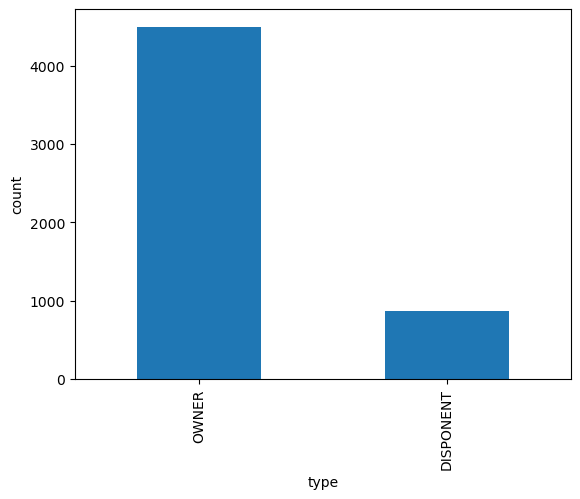

In [28]:
disp['type'].value_counts().plot(kind ='bar',ylabel='count')

In [29]:
#select only owner

disp_base = disp[disp['type']=='OWNER']
disp_base.head()

,disp_id,client_id,account_id,type
0,1,1,1,OWNER
1,2,2,2,OWNER
3,4,4,3,OWNER
5,6,6,4,OWNER
6,7,7,5,OWNER


In [30]:
disp_base['type'].nunique()

1

In [31]:
disp_base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4500 entries, 0 to 5368
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   disp_id     4500 non-null   int64 
 1   client_id   4500 non-null   int64 
 2   account_id  4500 non-null   int64 
 3   type        4500 non-null   object
dtypes: int64(3), object(1)
memory usage: 175.8+ KB


In [32]:
order.head()

,order_id,account_id,bank_to,account_to,amount,k_symbol
0,29401,1,YZ,87144583,2452.0,SIPO
1,29402,2,ST,89597016,3372.7,UVER
2,29403,2,QR,13943797,7266.0,SIPO
3,29404,3,WX,83084338,1135.0,SIPO
4,29405,3,CD,24485939,327.0,


In [33]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6471 entries, 0 to 6470
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    6471 non-null   int64  
 1   account_id  6471 non-null   int64  
 2   bank_to     6471 non-null   object 
 3   account_to  6471 non-null   int64  
 4   amount      6471 non-null   float64
 5   k_symbol    6471 non-null   object 
dtypes: float64(1), int64(3), object(2)
memory usage: 303.5+ KB


In [34]:
#filtering account owner
order_owner = order[order['account_id'].isin(disp['account_id'])]

In [35]:
order_owner.shape

(6471, 6)

In [36]:
order_owner.isna().sum()

order_id      0
account_id    0
bank_to       0
account_to    0
amount        0
k_symbol      0
dtype: int64

In [37]:
order_owner['k_symbol'].value_counts()

k_symbol
SIPO        3502
            1379
UVER         717
POJISTNE     532
LEASING      341
Name: count, dtype: int64

In [38]:
def convert_order_k_symbol_to_eng(x):
    if x == 'POJISTNE':
        return 'Insurance payment'
    elif x == 'SIPO':
        return 'Household'
    elif x == 'LEASING':
        return 'Leasing'
    elif x == 'UVER':
        return 'Loan payment'
    else:
        return np.nan

In [39]:
order_owner['k_symbol_eng'] = order_owner['k_symbol'].apply(convert_order_k_symbol_to_eng)
order_owner.head()

,order_id,account_id,bank_to,account_to,amount,k_symbol,k_symbol_eng
0,29401,1,YZ,87144583,2452.0,SIPO,Household
1,29402,2,ST,89597016,3372.7,UVER,Loan payment
2,29403,2,QR,13943797,7266.0,SIPO,Household
3,29404,3,WX,83084338,1135.0,SIPO,Household
4,29405,3,CD,24485939,327.0,,NaN


In [40]:
order_base = order_owner.drop('k_symbol',axis=1)
order_base.head()

,order_id,account_id,bank_to,account_to,amount,k_symbol_eng
0,29401,1,YZ,87144583,2452.0,Household
1,29402,2,ST,89597016,3372.7,Loan payment
2,29403,2,QR,13943797,7266.0,Household
3,29404,3,WX,83084338,1135.0,Household
4,29405,3,CD,24485939,327.0,NaN


In [41]:
#getting the features of orders by agg them and converting category to 1 and 0
order_features = order_base.groupby('account_id').agg(
    num_orders_1996=('order_id', 'count'),
    total_order_amount_1996=('amount', 'sum'),
    has_insurance_order_1996=('k_symbol_eng', lambda x: int('Insurance payment' in x.values)),
    has_household_order_1996=('k_symbol_eng', lambda x: int('Household' in x.values)),
    has_leasing_order_1996=('k_symbol_eng', lambda x: int('Leasing' in x.values)),
    has_loan_repayment_order_1996=('k_symbol_eng', lambda x: int('Loan payment' in x.values))
).reset_index()

In [42]:

order_features.head()

,account_id,num_orders_1996,total_order_amount_1996,has_insurance_order_1996,has_household_order_1996,has_leasing_order_1996,has_loan_repayment_order_1996
0,1,1,2452.0,0,1,0,0
1,2,2,10638.7,0,1,0,1
2,3,3,5001.0,1,1,0,0
3,4,2,3363.0,0,1,0,0
4,5,1,2668.0,0,1,0,0


In [43]:
order_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3758 entries, 0 to 3757
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   account_id                     3758 non-null   int64  
 1   num_orders_1996                3758 non-null   int64  
 2   total_order_amount_1996        3758 non-null   float64
 3   has_insurance_order_1996       3758 non-null   int64  
 4   has_household_order_1996       3758 non-null   int64  
 5   has_leasing_order_1996         3758 non-null   int64  
 6   has_loan_repayment_order_1996  3758 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 205.6 KB


In [44]:
trans.head()

,trans_id,account_id,date,type,operation,amount,balance,k_symbol,bank,account
0,695247,2378,930101,PRIJEM,VKLAD,700.0,700.0,NaN,NaN,NaN
1,171812,576,930101,PRIJEM,VKLAD,900.0,900.0,NaN,NaN,NaN
2,207264,704,930101,PRIJEM,VKLAD,1000.0,1000.0,NaN,NaN,NaN
3,1117247,3818,930101,PRIJEM,VKLAD,600.0,600.0,NaN,NaN,NaN
4,579373,1972,930102,PRIJEM,VKLAD,400.0,400.0,NaN,NaN,NaN


In [45]:
trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056320 entries, 0 to 1056319
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   trans_id    1056320 non-null  int64  
 1   account_id  1056320 non-null  int64  
 2   date        1056320 non-null  int64  
 3   type        1056320 non-null  object 
 4   operation   873206 non-null   object 
 5   amount      1056320 non-null  float64
 6   balance     1056320 non-null  float64
 7   k_symbol    574439 non-null   object 
 8   bank        273508 non-null   object 
 9   account     295389 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 80.6+ MB


In [46]:
trans.isna().sum()

trans_id           0
account_id         0
date               0
type               0
operation     183114
amount             0
balance            0
k_symbol      481881
bank          782812
account       760931
dtype: int64

In [47]:
trans['type'].value_counts()

type
VYDAJ     634571
PRIJEM    405083
VYBER      16666
Name: count, dtype: int64

In [48]:
trans['operation'].value_counts()

operation
VYBER             434918
PREVOD NA UCET    208283
VKLAD             156743
PREVOD Z UCTU      65226
VYBER KARTOU        8036
Name: count, dtype: int64

In [49]:
trans['k_symbol'].value_counts()

k_symbol
UROK           183114
SLUZBY         155832
SIPO           118065
                53433
DUCHOD          30338
POJISTNE        18500
UVER            13580
SANKC. UROK      1577
Name: count, dtype: int64

In [50]:
def convert_trans_type_to_eng(x):
    if x == 'PRIJEM':
        return 'Credit'
    else:
        return 'Withdrawal'
    
def convert_trans_op_to_eng(x):
    if x == 'VYBER KARTOU':
        return 'Credit card withdrawal'
    elif x == 'VKLAD':
        return 'Credit in cash'
    elif x == 'PREVOD Z UCTU':
        return 'Collection from another bank'
    elif x == 'VYBER':
        return 'Withdrawal in Cash'
    elif x == 'PREVOD NA UCET':
        return 'Remittance to another bank'    
    else:
        return np.nan
def convert_trans_k_symbol_to_eng(x):
    if x == 'POJISTNE':
        return 'Insurance payment'
    elif x == 'SLUZBY':
        return 'Payment for statement'
    elif x == 'UROK':
        return 'Interest credited'
    elif x == 'SANKC. UROK':
        return 'Sanction interest if negative balance'
    elif x == 'SIPO':
        return 'Household'
    elif x == 'DUCHOD':
        return 'Old-age pension'  
    elif x == 'UVER':
        return 'Loan payment'      
    else:
        return np.nan

In [51]:
trans['trans_type_eng'] = trans['type'].map(convert_trans_type_to_eng)
trans['trans_operation_eng'] = trans['operation'].map(convert_trans_op_to_eng)
trans['trans_k_symbol_eng'] = trans['k_symbol'].map(convert_trans_k_symbol_to_eng)

In [52]:
# drop original columns after modified
trans_base= trans.drop(['type', 'operation','k_symbol'], axis=1)
trans_base.head()

,trans_id,account_id,date,amount,balance,bank,account,trans_type_eng,trans_operation_eng,trans_k_symbol_eng
0,695247,2378,930101,700.0,700.0,NaN,NaN,Credit,Credit in cash,NaN
1,171812,576,930101,900.0,900.0,NaN,NaN,Credit,Credit in cash,NaN
2,207264,704,930101,1000.0,1000.0,NaN,NaN,Credit,Credit in cash,NaN
3,1117247,3818,930101,600.0,600.0,NaN,NaN,Credit,Credit in cash,NaN
4,579373,1972,930102,400.0,400.0,NaN,NaN,Credit,Credit in cash,NaN


In [53]:
trans_base.isna().sum()

trans_id                    0
account_id                  0
date                        0
amount                      0
balance                     0
bank                   782812
account                760931
trans_type_eng              0
trans_operation_eng    183114
trans_k_symbol_eng     535314
dtype: int64

In [54]:
#merging client , account, orders and disp
df = disp_base.merge(client,on='client_id',how='left')
df = df.merge(account_base,on='account_id',how='left')
df = df.merge(order_features,on='account_id',how='left')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   disp_id                        4500 non-null   int64  
 1   client_id                      4500 non-null   int64  
 2   account_id                     4500 non-null   int64  
 3   type                           4500 non-null   object 
 4   birth_number                   4500 non-null   int64  
 5   district_id_x                  4500 non-null   int64  
 6   birth_year                     4500 non-null   int64  
 7   birth_month                    4500 non-null   int64  
 8   gender                         4500 non-null   object 
 9   birth_day                      4500 non-null   int64  
 10  age                            4500 non-null   int64  
 11  age_group                      4500 non-null   int64  
 12  district_id_y                  4500 non-null   i

In [55]:
#1996 all data of idv
df = df[df['year']< 1996]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2239 entries, 0 to 4499
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   disp_id                        2239 non-null   int64  
 1   client_id                      2239 non-null   int64  
 2   account_id                     2239 non-null   int64  
 3   type                           2239 non-null   object 
 4   birth_number                   2239 non-null   int64  
 5   district_id_x                  2239 non-null   int64  
 6   birth_year                     2239 non-null   int64  
 7   birth_month                    2239 non-null   int64  
 8   gender                         2239 non-null   object 
 9   birth_day                      2239 non-null   int64  
 10  age                            2239 non-null   int64  
 11  age_group                      2239 non-null   int64  
 12  district_id_y                  2239 non-null   int64 

In [56]:
trans96 = trans_base[trans_base['date'].astype(str).str[:2].isin(['96'])]
trans_agg_credit = trans96[trans96['trans_type_eng'].isin(['Credit'])].groupby('account_id')['amount'].agg('sum')
trans_agg_credit = trans_agg_credit.reset_index()
trans_agg_credit = trans_agg_credit.rename(columns={'amount':'total_credit'})
trans_agg_credit.head()

,account_id,total_credit
0,1,50066.0
1,2,288542.9
2,4,56920.5
3,6,81507.7
4,7,34905.4


In [57]:
trans_agg_withdrawal = trans96[trans96['trans_type_eng'].isin(['Withdrawal'])].groupby('account_id')['amount'].agg('sum')
trans_agg_withdrawal = trans_agg_withdrawal.reset_index()
trans_agg_withdrawal = trans_agg_withdrawal.rename(columns={'amount':'total_withdrawal'})
trans_agg_withdrawal.head()

,account_id,total_withdrawal
0,1,55579.2
1,2,274574.2
2,4,31977.6
3,6,81803.2
4,7,6600.0


In [58]:
transtransaction_counts = trans96.groupby('account_id').agg(total_transactions=('trans_id', 'count')).reset_index()

In [59]:
transtransaction_balance = trans96.groupby('account_id').agg(balance_mean=('balance', 'mean'),balance_std=('balance', 'std')).reset_index()

In [60]:
trans96.head()

,trans_id,account_id,date,amount,balance,bank,account,trans_type_eng,trans_operation_eng,trans_k_symbol_eng
252855,732811,2504,960101,900.0,38124.4,NaN,0.0,Withdrawal,Credit card withdrawal,NaN
252856,800209,2729,960101,1920.0,34202.7,NaN,NaN,Withdrawal,Withdrawal in Cash,NaN
252857,803553,2738,960101,6500.0,25685.2,NaN,NaN,Withdrawal,Withdrawal in Cash,NaN
252858,1042686,3566,960101,1000.0,25919.7,NaN,NaN,Withdrawal,Withdrawal in Cash,NaN
252859,1042689,3566,960101,500.0,25419.7,NaN,NaN,Withdrawal,Withdrawal in Cash,NaN


In [61]:
operation_counts = trans96.groupby('account_id').agg(
    credit_card_withdraw_count=('trans_operation_eng', lambda x: (x == 'Credit card withdrawal').sum()),
    cash_deposit_count=('trans_operation_eng', lambda x: (x == 'Credit in cash').sum()),
    interbank_in_count=('trans_operation_eng', lambda x: (x == 'Collection from another bank').sum()),
    interbank_out_count=('trans_operation_eng', lambda x: (x == 'Withdrawal in Cash').sum()),
    cash_withdrawal_count=('trans_operation_eng', lambda x: (x == 'Remittance to another bank').sum())
).reset_index()

In [62]:
k_symbol_counts = trans96.groupby('account_id').agg(
    insurance_payment_count=('trans_k_symbol_eng', lambda x: (x == 'Insurance payment').sum()),
    services_payment_count=('trans_k_symbol_eng', lambda x: (x == 'Payment for statement').sum()),
    interest_credit_count=('trans_k_symbol_eng', lambda x: (x == 'Interest credited').sum()),
    sanction_interest_count=('trans_k_symbol_eng', lambda x: (x == 'Sanction interest if negative balance').sum()),
    household_payment_count=('trans_k_symbol_eng', lambda x: (x == 'Household').sum()),
    pension_credit_count=('trans_k_symbol_eng', lambda x: (x == 'Old-age pension').sum()),
    loan_payment_count=('trans_k_symbol_eng', lambda x: (x == 'Loan payment').sum())
).reset_index()

In [63]:
df = pd.merge(df, trans_agg_credit, how='left', on='account_id')
df = pd.merge(df, trans_agg_withdrawal, how='left', on='account_id')
df = pd.merge(df, transtransaction_counts, how='left', on='account_id')
df = pd.merge(df, transtransaction_balance, how='left', on='account_id')
df = pd.merge(df, operation_counts , how='left', on='account_id')
df = pd.merge(df, k_symbol_counts , how='left', on='account_id')

df.head()

,disp_id,client_id,account_id,type,birth_number,district_id_x,birth_year,birth_month,gender,birth_day,...,interbank_in_count,interbank_out_count,cash_withdrawal_count,insurance_payment_count,services_payment_count,interest_credit_count,sanction_interest_count,household_payment_count,pension_credit_count,loan_payment_count
0,1,1,1,OWNER,706213,18,1970,12,F,13,...,12,33,12,0,12,12,0,12,0,0
1,2,2,2,OWNER,450204,1,1945,2,M,4,...,12,44,12,0,12,12,0,12,0,0
2,8,8,6,OWNER,385221,51,1938,2,F,21,...,12,27,12,0,12,12,0,12,12,0
3,10,10,8,OWNER,430501,57,1943,5,M,1,...,0,30,21,0,11,12,0,11,0,0
4,12,12,9,OWNER,810220,40,1981,2,M,20,...,0,38,0,0,12,12,0,0,0,0


In [64]:
df = df.rename(columns={'district_id_x':'bank_district_id',
                        'district_id_y':'client_district_id'})
df.head()

,disp_id,client_id,account_id,type,birth_number,bank_district_id,birth_year,birth_month,gender,birth_day,...,interbank_in_count,interbank_out_count,cash_withdrawal_count,insurance_payment_count,services_payment_count,interest_credit_count,sanction_interest_count,household_payment_count,pension_credit_count,loan_payment_count
0,1,1,1,OWNER,706213,18,1970,12,F,13,...,12,33,12,0,12,12,0,12,0,0
1,2,2,2,OWNER,450204,1,1945,2,M,4,...,12,44,12,0,12,12,0,12,0,0
2,8,8,6,OWNER,385221,51,1938,2,F,21,...,12,27,12,0,12,12,0,12,12,0
3,10,10,8,OWNER,430501,57,1943,5,M,1,...,0,30,21,0,11,12,0,11,0,0
4,12,12,9,OWNER,810220,40,1981,2,M,20,...,0,38,0,0,12,12,0,0,0,0


In [65]:
# ensure 'date' is string and formatted correctly
trans96['date'] = trans96['date'].astype(str)

# convert YYMMDD → proper datetime
trans96['date'] = pd.to_datetime('19' + trans96['date'], format='%Y%m%d', errors='coerce')

# group to compute RFM
rfm = trans96.groupby('account_id').agg(
    frequency=('trans_id', 'count'),
    monetary=('amount', 'sum'),
    last_trans_date=('date', 'max')
).reset_index()

# compute recency in days relative to Dec 31, 1996
reference_date = pd.Timestamp('1996-12-31')
rfm['recency'] = (reference_date - rfm['last_trans_date']).dt.days
rfm.head()

C:\Users\Source\AppData\Local\Temp\ipykernel_10056\353394754.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trans96['date'] = trans96['date'].astype(str)
C:\Users\Source\AppData\Local\Temp\ipykernel_10056\353394754.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trans96['date'] = pd.to_datetime('19' + trans96['date'], format='%Y%m%d', errors='coerce')


,account_id,frequency,monetary,last_trans_date,recency
0,1,74,105645.2,1996-12-31,0
1,2,85,563117.1,1996-12-31,0
2,4,39,88898.1,1996-12-31,0
3,6,63,163310.9,1996-12-31,0
4,7,4,41505.4,1996-12-31,0


In [66]:
df= df.merge(rfm,on='account_id',how='left')
df.head()

,disp_id,client_id,account_id,type,birth_number,bank_district_id,birth_year,birth_month,gender,birth_day,...,services_payment_count,interest_credit_count,sanction_interest_count,household_payment_count,pension_credit_count,loan_payment_count,frequency,monetary,last_trans_date,recency
0,1,1,1,OWNER,706213,18,1970,12,F,13,...,12,12,0,12,0,0,74,105645.2,1996-12-31,0
1,2,2,2,OWNER,450204,1,1945,2,M,4,...,12,12,0,12,0,0,85,563117.1,1996-12-31,0
2,8,8,6,OWNER,385221,51,1938,2,F,21,...,12,12,0,12,12,0,63,163310.9,1996-12-31,0
3,10,10,8,OWNER,430501,57,1943,5,M,1,...,11,12,0,11,0,0,75,543205.8,1996-12-31,0
4,12,12,9,OWNER,810220,40,1981,2,M,20,...,12,12,0,0,0,0,66,103347.4,1996-12-31,0


In [67]:
district['A15'] = district['A15'].replace('?', np.nan).astype(float)
district['A12'] = district['A12'].replace('?', np.nan).astype(float)

In [68]:
df = df.merge(district,how='left',left_on='client_district_id',right_on='A1')

In [69]:
df = df.drop(columns=['A1'])

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2239 entries, 0 to 2238
Data columns (total 59 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   disp_id                        2239 non-null   int64         
 1   client_id                      2239 non-null   int64         
 2   account_id                     2239 non-null   int64         
 3   type                           2239 non-null   object        
 4   birth_number                   2239 non-null   int64         
 5   bank_district_id               2239 non-null   int64         
 6   birth_year                     2239 non-null   int64         
 7   birth_month                    2239 non-null   int64         
 8   gender                         2239 non-null   object        
 9   birth_day                      2239 non-null   int64         
 10  age                            2239 non-null   int64         
 11  age_group        

In [71]:
df.head()

,disp_id,client_id,account_id,type,birth_number,bank_district_id,birth_year,birth_month,gender,birth_day,...,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,1,1,1,OWNER,706213,18,1970,12,F,13,...,2,1,4,65.3,8968,2.83,3.35,131,1740.0,1910
1,2,2,2,OWNER,450204,1,1945,2,M,4,...,0,1,1,100.0,12541,0.29,0.43,167,85677.0,99107
2,8,8,6,OWNER,385221,51,1938,2,F,21,...,7,3,11,70.5,8541,2.51,2.97,131,3496.0,3839
3,10,10,8,OWNER,430501,57,1943,5,M,1,...,20,3,8,48.0,8720,3.73,4.50,116,3729.0,3651
4,12,12,9,OWNER,810220,40,1981,2,M,20,...,8,5,7,89.9,10177,6.63,7.75,81,9878.0,10108


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2239 entries, 0 to 2238
Data columns (total 59 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   disp_id                        2239 non-null   int64         
 1   client_id                      2239 non-null   int64         
 2   account_id                     2239 non-null   int64         
 3   type                           2239 non-null   object        
 4   birth_number                   2239 non-null   int64         
 5   bank_district_id               2239 non-null   int64         
 6   birth_year                     2239 non-null   int64         
 7   birth_month                    2239 non-null   int64         
 8   gender                         2239 non-null   object        
 9   birth_day                      2239 non-null   int64         
 10  age                            2239 non-null   int64         
 11  age_group        

In [73]:
df.isnull().sum()

disp_id                            0
client_id                          0
account_id                         0
type                               0
birth_number                       0
bank_district_id                   0
birth_year                         0
birth_month                        0
gender                             0
birth_day                          0
age                                0
age_group                          0
client_district_id                 0
date                               0
year                               0
lor                                0
frequency_eng                      0
num_orders_1996                  380
total_order_amount_1996          380
has_insurance_order_1996         380
has_household_order_1996         380
has_leasing_order_1996           380
has_loan_repayment_order_1996    380
total_credit                       1
total_withdrawal                   0
total_transactions                 0
balance_mean                       0
b

In [74]:
df = df.fillna(0)
df.isnull().sum().sum()

np.int64(0)

In [75]:
int_cols = [
    'num_orders_1996',
    'has_insurance_order_1996',
    'has_household_order_1996',
    'has_leasing_order_1996',
    'has_loan_repayment_order_1996'
]

df[int_cols] = df[int_cols].astype(int)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2239 entries, 0 to 2238
Data columns (total 59 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   disp_id                        2239 non-null   int64         
 1   client_id                      2239 non-null   int64         
 2   account_id                     2239 non-null   int64         
 3   type                           2239 non-null   object        
 4   birth_number                   2239 non-null   int64         
 5   bank_district_id               2239 non-null   int64         
 6   birth_year                     2239 non-null   int64         
 7   birth_month                    2239 non-null   int64         
 8   gender                         2239 non-null   object        
 9   birth_day                      2239 non-null   int64         
 10  age                            2239 non-null   int64         
 11  age_group        

In [77]:
df.head()

,disp_id,client_id,account_id,type,birth_number,bank_district_id,birth_year,birth_month,gender,birth_day,...,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,1,1,1,OWNER,706213,18,1970,12,F,13,...,2,1,4,65.3,8968,2.83,3.35,131,1740.0,1910
1,2,2,2,OWNER,450204,1,1945,2,M,4,...,0,1,1,100.0,12541,0.29,0.43,167,85677.0,99107
2,8,8,6,OWNER,385221,51,1938,2,F,21,...,7,3,11,70.5,8541,2.51,2.97,131,3496.0,3839
3,10,10,8,OWNER,430501,57,1943,5,M,1,...,20,3,8,48.0,8720,3.73,4.50,116,3729.0,3651
4,12,12,9,OWNER,810220,40,1981,2,M,20,...,8,5,7,89.9,10177,6.63,7.75,81,9878.0,10108


In [78]:
# working on dependent variable

In [79]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   loan_id     682 non-null    int64  
 1   account_id  682 non-null    int64  
 2   date        682 non-null    int64  
 3   amount      682 non-null    int64  
 4   duration    682 non-null    int64  
 5   payments    682 non-null    float64
 6   status      682 non-null    object 
dtypes: float64(1), int64(5), object(1)
memory usage: 37.4+ KB


In [80]:
loan['year'] = 1900 + loan['date'].astype(str).str[:2].astype(int)
loan_1997 = loan[loan['year'] == 1997]  
loan_1997.shape
loan_1997 = loan_1997[['loan_id','account_id']]
loan_1997.shape

(196, 2)

In [81]:
loan_clients_1997 = loan_1997.merge(disp_base, on='account_id',how='left')
loan_clients_1997 = loan_clients_1997[['loan_id','account_id']]
loan_clients_1997.head()

,loan_id,account_id
0,5895,4473
1,7122,10365
2,6173,5724
3,6142,5591
4,5358,2018


In [82]:
loan_clients_1997.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   loan_id     196 non-null    int64
 1   account_id  196 non-null    int64
dtypes: int64(2)
memory usage: 3.2 KB


In [83]:
df['loan_1997'] = df['account_id'].isin(loan_clients_1997['account_id']).astype(int)
df.head()

,disp_id,client_id,account_id,type,birth_number,bank_district_id,birth_year,birth_month,gender,birth_day,...,A8,A9,A10,A11,A12,A13,A14,A15,A16,loan_1997
0,1,1,1,OWNER,706213,18,1970,12,F,13,...,1,4,65.3,8968,2.83,3.35,131,1740.0,1910,0
1,2,2,2,OWNER,450204,1,1945,2,M,4,...,1,1,100.0,12541,0.29,0.43,167,85677.0,99107,0
2,8,8,6,OWNER,385221,51,1938,2,F,21,...,3,11,70.5,8541,2.51,2.97,131,3496.0,3839,0
3,10,10,8,OWNER,430501,57,1943,5,M,1,...,3,8,48.0,8720,3.73,4.50,116,3729.0,3651,0
4,12,12,9,OWNER,810220,40,1981,2,M,20,...,5,7,89.9,10177,6.63,7.75,81,9878.0,10108,0


In [84]:
df['loan_1997'].value_counts()

loan_1997
0    2208
1      31
Name: count, dtype: int64

In [85]:
card.head()

,card_id,disp_id,type,issued
0,1005,9285,classic,931107 00:00:00
1,104,588,classic,940119 00:00:00
2,747,4915,classic,940205 00:00:00
3,70,439,classic,940208 00:00:00
4,577,3687,classic,940215 00:00:00


In [86]:
card['year'] = 1900 + card['issued'].astype(str).str[:2].astype(int)
card_1997 = card[card['year'] == 1997]
card_clients_1997 = (
    card_1997
    .merge(disp_base, on='disp_id')
)

In [87]:
card_clients_1997.head()

,card_id,disp_id,type_x,issued,year,client_id,account_id,type_y
0,1118,11393,classic,970102 00:00:00,1997,11701,9504,OWNER
1,175,1040,classic,970103 00:00:00,1997,1040,863,OWNER
2,565,3601,gold,970106 00:00:00,1997,3601,2982,OWNER
3,714,4638,classic,970109 00:00:00,1997,4638,3847,OWNER
4,137,786,junior,970110 00:00:00,1997,786,655,OWNER


In [88]:
#card_1997 = 1 means the client had a credit card issued in 1997.
df['card_1997'] = df['client_id'].isin(card_clients_1997['client_id']).astype(int) 
df.head()

,disp_id,client_id,account_id,type,birth_number,bank_district_id,birth_year,birth_month,gender,birth_day,...,A9,A10,A11,A12,A13,A14,A15,A16,loan_1997,card_1997
0,1,1,1,OWNER,706213,18,1970,12,F,13,...,4,65.3,8968,2.83,3.35,131,1740.0,1910,0,0
1,2,2,2,OWNER,450204,1,1945,2,M,4,...,1,100.0,12541,0.29,0.43,167,85677.0,99107,0,0
2,8,8,6,OWNER,385221,51,1938,2,F,21,...,11,70.5,8541,2.51,2.97,131,3496.0,3839,0,0
3,10,10,8,OWNER,430501,57,1943,5,M,1,...,8,48.0,8720,3.73,4.50,116,3729.0,3651,0,0
4,12,12,9,OWNER,810220,40,1981,2,M,20,...,7,89.9,10177,6.63,7.75,81,9878.0,10108,0,0


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2239 entries, 0 to 2238
Data columns (total 61 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   disp_id                        2239 non-null   int64         
 1   client_id                      2239 non-null   int64         
 2   account_id                     2239 non-null   int64         
 3   type                           2239 non-null   object        
 4   birth_number                   2239 non-null   int64         
 5   bank_district_id               2239 non-null   int64         
 6   birth_year                     2239 non-null   int64         
 7   birth_month                    2239 non-null   int64         
 8   gender                         2239 non-null   object        
 9   birth_day                      2239 non-null   int64         
 10  age                            2239 non-null   int64         
 11  age_group        

In [90]:
# reduced columns (removig id)
idv_columns = [
    'client_id',
    'gender', 'age', 'age_group',
    'lor', 'frequency_eng',
    'num_orders_1996', 'total_order_amount_1996',
    'has_insurance_order_1996', 'has_household_order_1996',
    'has_leasing_order_1996', 'has_loan_repayment_order_1996',
    'total_credit', 'total_withdrawal', 
    'total_transactions',
    'balance_mean',
    'balance_std',
    'credit_card_withdraw_count',
    'cash_deposit_count',
    'interbank_in_count',
    'interbank_out_count',
    'cash_withdrawal_count',
    'insurance_payment_count',
    'services_payment_count',
    'interest_credit_count',
    'sanction_interest_count',
    'household_payment_count',
    'pension_credit_count',
    'loan_payment_count','frequency', 'monetary', 'recency','A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 
    'A11', 'A12', 'A13', 'A14', 'A15', 'A16',
    'loan_1997', 'card_1997'  # target variables
]

In [91]:
base_table = df[idv_columns]

In [92]:
base_table.head()

,client_id,gender,age,age_group,lor,frequency_eng,num_orders_1996,total_order_amount_1996,has_insurance_order_1996,has_household_order_1996,...,A9,A10,A11,A12,A13,A14,A15,A16,loan_1997,card_1997
0,1,F,29,20,1,MONTHLY,1,2452.0,0,1,...,4,65.3,8968,2.83,3.35,131,1740.0,1910,0,0
1,2,M,54,50,3,MONTHLY,2,10638.7,0,1,...,1,100.0,12541,0.29,0.43,167,85677.0,99107,0,0
2,8,F,61,60,2,MONTHLY,1,3954.0,0,1,...,11,70.5,8541,2.51,2.97,131,3496.0,3839,0,0
3,10,M,56,50,1,MONTHLY,2,9324.0,0,1,...,8,48.0,8720,3.73,4.50,116,3729.0,3651,0,0
4,12,M,18,10,3,MONTHLY,0,0.0,0,0,...,7,89.9,10177,6.63,7.75,81,9878.0,10108,0,0


In [93]:
base_table['credit_to_withdrawal_ratio'] = base_table['total_credit'] / base_table['total_withdrawal'].replace(0, 1)

C:\Users\Source\AppData\Local\Temp\ipykernel_10056\1138532444.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base_table['credit_to_withdrawal_ratio'] = base_table['total_credit'] / base_table['total_withdrawal'].replace(0, 1)


In [94]:
# --- Net cash flow features ---
base_table['net_cash_flow'] = base_table['total_credit'] - base_table['total_withdrawal']
base_table['net_cash_flow_ratio'] = base_table['net_cash_flow'] / base_table['total_transactions'].replace(0, 1)

# --- Ratios to balance ---
base_table['credit_to_balance_ratio'] = base_table['total_credit'] / base_table['balance_mean'].replace(0, 1)
base_table['withdrawal_to_balance_ratio'] = base_table['total_withdrawal'] / base_table['balance_mean'].replace(0, 1)
base_table['loan_to_credit_ratio'] = base_table['loan_payment_count'] / base_table['total_credit'].replace(0, 1)
base_table['interbank_ratio'] = (base_table['interbank_in_count'] + base_table['interbank_out_count']) / base_table['total_transactions'].replace(0, 1)

# --- Transaction variability ---
base_table['withdrawal_std_ratio'] = base_table['balance_std'] / base_table['total_withdrawal'].replace(0, 1)
base_table['credit_std_ratio'] = base_table['balance_std'] / base_table['total_credit'].replace(0, 1)

# --- Product/service engagement ratios ---
base_table['insurance_ratio'] = base_table['insurance_payment_count'] / base_table['total_transactions'].replace(0, 1)
base_table['loan_ratio'] = base_table['loan_payment_count'] / base_table['total_transactions'].replace(0, 1)
base_table['household_ratio'] = base_table['household_payment_count'] / base_table['total_transactions'].replace(0, 1)

C:\Users\Source\AppData\Local\Temp\ipykernel_10056\1395846384.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base_table['net_cash_flow'] = base_table['total_credit'] - base_table['total_withdrawal']
C:\Users\Source\AppData\Local\Temp\ipykernel_10056\1395846384.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base_table['net_cash_flow_ratio'] = base_table['net_cash_flow'] / base_table['total_transactions'].replace(0, 1)
C:\Users\Source\AppData\Local\Temp\ipykernel_10056\1395846384.py:6: SettingWithCo

In [95]:
# --- Behavioral flags ---
base_table['is_active_customer'] = (base_table['total_transactions'] > 100).astype(int)  # threshold 
base_table['relies_on_credit'] = (base_table['total_credit'] > base_table['total_withdrawal']).astype(int)

# --- Risk/stability indicators ---
base_table['sanction_interest_ratio'] = base_table['sanction_interest_count'] / base_table['total_transactions'].replace(0, 1)
base_table['volatility_index'] = base_table['balance_std'] / base_table['balance_mean'].replace(0, 1)

In [96]:
base_table.head()

,client_id,gender,age,age_group,lor,frequency_eng,num_orders_1996,total_order_amount_1996,has_insurance_order_1996,has_household_order_1996,...,interbank_ratio,withdrawal_std_ratio,credit_std_ratio,insurance_ratio,loan_ratio,household_ratio,is_active_customer,relies_on_credit,sanction_interest_ratio,volatility_index
0,1,F,29,20,1,MONTHLY,1,2452.0,0,1,...,0.608108,0.039081,0.043385,0.0,0.0,0.162162,0,0,0.0,0.135919
1,2,M,54,50,3,MONTHLY,2,10638.7,0,1,...,0.658824,0.042847,0.040773,0.0,0.0,0.141176,0,1,0.0,0.321404
2,8,F,61,60,2,MONTHLY,1,3954.0,0,1,...,0.619048,0.053514,0.053708,0.0,0.0,0.190476,0,0,0.0,0.142821
3,10,M,56,50,1,MONTHLY,2,9324.0,0,1,...,0.400000,0.034355,0.035079,0.0,0.0,0.146667,0,0,0.0,0.182507
4,12,M,18,10,3,MONTHLY,0,0.0,0,0,...,0.575758,0.151115,0.392622,0.0,0.0,0.000000,0,0,0.0,0.347469


In [97]:
#base table analysis

<Axes: ylabel='Frequency'>

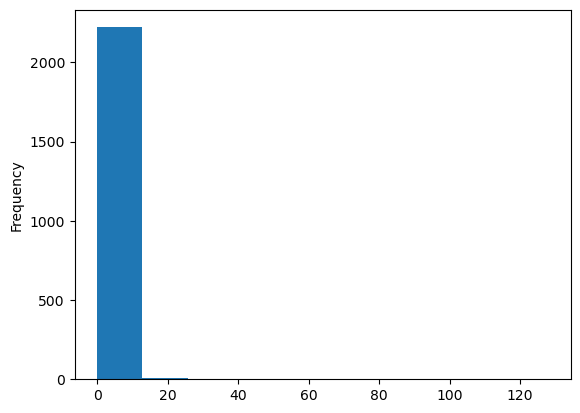

In [98]:
base_table['recency'].plot(kind='hist')

<Axes: >

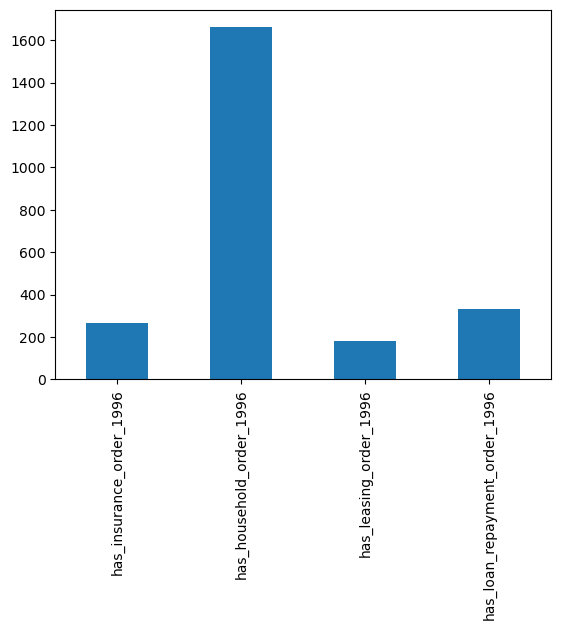

In [99]:
base_table[['has_insurance_order_1996','has_household_order_1996','has_leasing_order_1996','has_loan_repayment_order_1996']].sum().plot(kind='bar')

<Axes: xlabel='gender'>

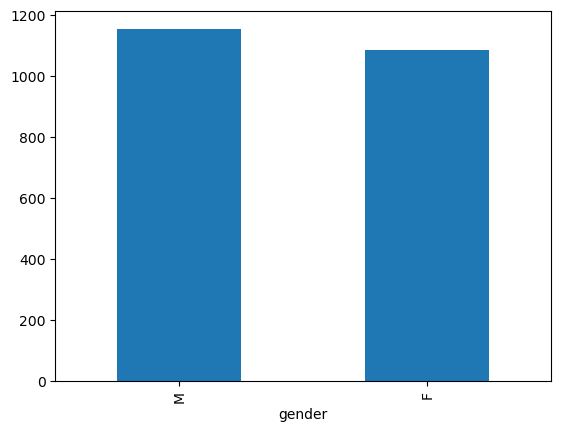

In [100]:
base_table['gender'].value_counts().plot(kind='bar')

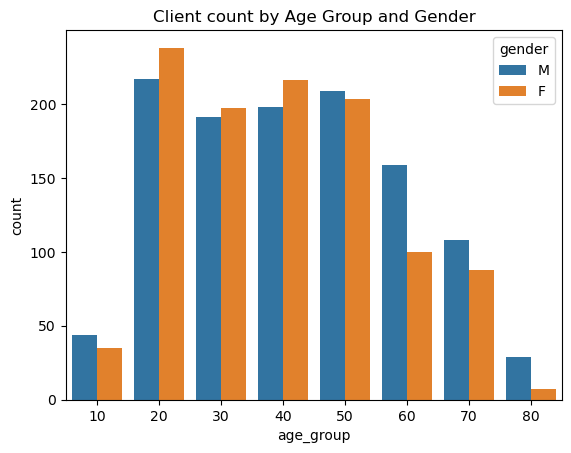

In [101]:
sns.countplot(data=df, x='age_group', hue='gender')
plt.title('Client count by Age Group and Gender')
plt.show()

<Axes: xlabel='gender'>

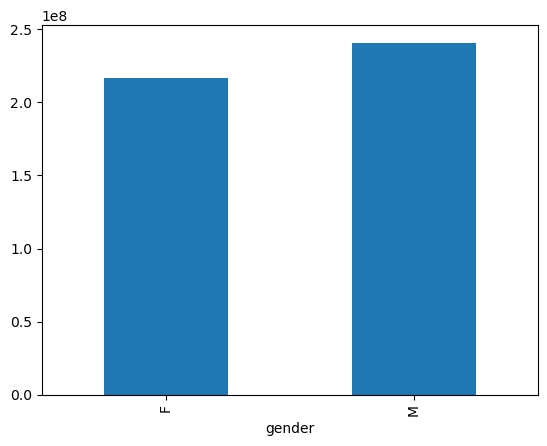

In [102]:
base_table.groupby('gender')['total_credit'].sum().plot(kind='bar')

In [103]:
base_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2239 entries, 0 to 2238
Data columns (total 65 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   client_id                      2239 non-null   int64  
 1   gender                         2239 non-null   object 
 2   age                            2239 non-null   int64  
 3   age_group                      2239 non-null   int64  
 4   lor                            2239 non-null   int64  
 5   frequency_eng                  2239 non-null   object 
 6   num_orders_1996                2239 non-null   int64  
 7   total_order_amount_1996        2239 non-null   float64
 8   has_insurance_order_1996       2239 non-null   int64  
 9   has_household_order_1996       2239 non-null   int64  
 10  has_leasing_order_1996         2239 non-null   int64  
 11  has_loan_repayment_order_1996  2239 non-null   int64  
 12  total_credit                   2239 non-null   f

In [104]:
base_table['age_group'] = base_table['age_group'].astype('category')

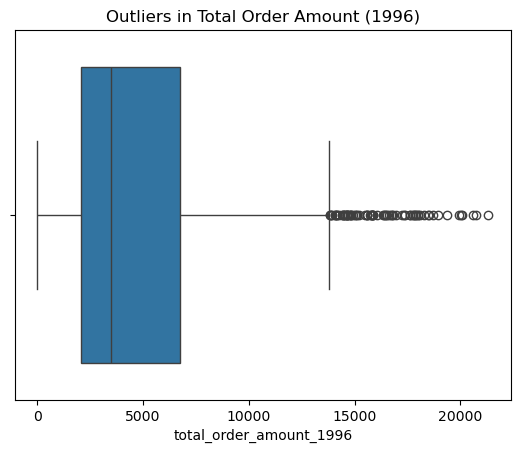

In [105]:
sns.boxplot(x=base_table['total_order_amount_1996'])
plt.title('Outliers in Total Order Amount (1996)')
plt.show()

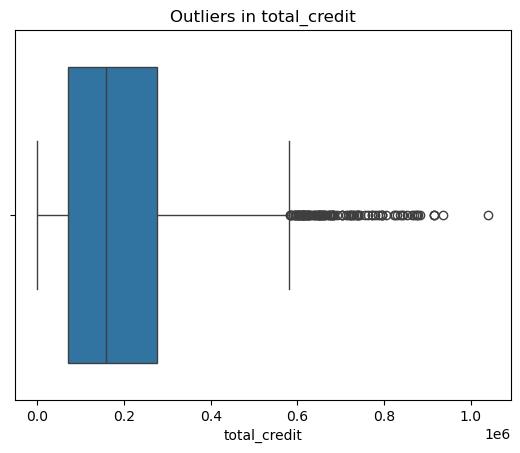

In [106]:
sns.boxplot(x=base_table['total_credit'])
plt.title('Outliers in total_credit')
plt.show()

In [107]:
Q1 = base_table['total_order_amount_1996'].quantile(0.25)
Q3 = base_table['total_order_amount_1996'].quantile(0.75)
IQR = Q3 - Q1

outliers = base_table[(base_table['total_order_amount_1996'] < Q1 - 1.5*IQR) | 
              (base_table['total_order_amount_1996'] > Q3 + 1.5*IQR)]
print("Outliers count:", len(outliers))

Outliers count: 77


In [108]:
# ✅ Rule of thumb for your task

# Tree-based models: leave outliers as-is.

# Linear/logistic models: consider log-transform for highly skewed numeric features.

# Never remove outliers blindly — they may be key indicators for getting a loan or card.

In [109]:
outliers = base_table[
    (base_table['total_order_amount_1996'] < Q1 - 1.5 * IQR) |
    (base_table['total_order_amount_1996'] > Q3 + 1.5 * IQR)
]
outliers.head()   

,client_id,gender,age,age_group,lor,frequency_eng,num_orders_1996,total_order_amount_1996,has_insurance_order_1996,has_household_order_1996,...,interbank_ratio,withdrawal_std_ratio,credit_std_ratio,insurance_ratio,loan_ratio,household_ratio,is_active_customer,relies_on_credit,sanction_interest_ratio,volatility_index
45,100,F,57,50,1,TRANSACTION,2,14161.0,0,1,...,0.388060,0.063366,0.053549,0.000000,0.0,0.134328,0,1,0.0,0.468925
86,210,M,60,60,3,MONTHLY,5,17342.0,1,1,...,0.355372,0.031480,0.033102,0.099174,0.0,0.099174,1,0,0.0,0.257914
101,255,F,48,40,3,WEEKLY,1,13841.0,0,1,...,0.686747,0.031053,0.030885,0.000000,0.0,0.144578,0,1,0.0,0.325866
124,310,M,49,40,1,MONTHLY,2,17982.7,0,1,...,0.433333,0.107798,0.264610,0.000000,0.0,0.033333,0,0,0.0,0.473228
171,444,F,39,30,3,MONTHLY,5,15090.0,1,1,...,0.380000,0.037498,0.039448,0.120000,0.0,0.120000,0,0,0.0,0.413533


In [110]:
base_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2239 entries, 0 to 2238
Data columns (total 65 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   client_id                      2239 non-null   int64   
 1   gender                         2239 non-null   object  
 2   age                            2239 non-null   int64   
 3   age_group                      2239 non-null   category
 4   lor                            2239 non-null   int64   
 5   frequency_eng                  2239 non-null   object  
 6   num_orders_1996                2239 non-null   int64   
 7   total_order_amount_1996        2239 non-null   float64 
 8   has_insurance_order_1996       2239 non-null   int64   
 9   has_household_order_1996       2239 non-null   int64   
 10  has_leasing_order_1996         2239 non-null   int64   
 11  has_loan_repayment_order_1996  2239 non-null   int64   
 12  total_credit                   223

In [111]:
#This the final base table - the client id is kept just to distinguish whcih can be removed before train test slpit.
base_table.head()

,client_id,gender,age,age_group,lor,frequency_eng,num_orders_1996,total_order_amount_1996,has_insurance_order_1996,has_household_order_1996,...,interbank_ratio,withdrawal_std_ratio,credit_std_ratio,insurance_ratio,loan_ratio,household_ratio,is_active_customer,relies_on_credit,sanction_interest_ratio,volatility_index
0,1,F,29,20,1,MONTHLY,1,2452.0,0,1,...,0.608108,0.039081,0.043385,0.0,0.0,0.162162,0,0,0.0,0.135919
1,2,M,54,50,3,MONTHLY,2,10638.7,0,1,...,0.658824,0.042847,0.040773,0.0,0.0,0.141176,0,1,0.0,0.321404
2,8,F,61,60,2,MONTHLY,1,3954.0,0,1,...,0.619048,0.053514,0.053708,0.0,0.0,0.190476,0,0,0.0,0.142821
3,10,M,56,50,1,MONTHLY,2,9324.0,0,1,...,0.400000,0.034355,0.035079,0.0,0.0,0.146667,0,0,0.0,0.182507
4,12,M,18,10,3,MONTHLY,0,0.0,0,0,...,0.575758,0.151115,0.392622,0.0,0.0,0.000000,0,0,0.0,0.347469


In [112]:
base_table.to_csv('base_table.csv')

In [113]:
base_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2239 entries, 0 to 2238
Data columns (total 65 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   client_id                      2239 non-null   int64   
 1   gender                         2239 non-null   object  
 2   age                            2239 non-null   int64   
 3   age_group                      2239 non-null   category
 4   lor                            2239 non-null   int64   
 5   frequency_eng                  2239 non-null   object  
 6   num_orders_1996                2239 non-null   int64   
 7   total_order_amount_1996        2239 non-null   float64 
 8   has_insurance_order_1996       2239 non-null   int64   
 9   has_household_order_1996       2239 non-null   int64   
 10  has_leasing_order_1996         2239 non-null   int64   
 11  has_loan_repayment_order_1996  2239 non-null   int64   
 12  total_credit                   223

In [114]:
target_cols = base_table[['loan_1997', 'card_1997']]
target_cols.head()

,loan_1997,card_1997
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
